In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle
%config InlineBackend.figure_format = 'retina'

In [2]:
N = 10
p = 3   

xi = np.linspace(0, 1, N + 1)
x_edges = 15 * (xi**p)   # 0~15 non-uniform mesh


In [3]:
xi = np.linspace(0, 1, N + 1)
x_edges = 15 * (1 - (1 - xi)**p)


In [4]:
def v_true(x):
    return 41 * (15 - x)**0.44

In [5]:
x_mid = 0.5 * (x_edges[:-1] + x_edges[1:])
v_piece = v_true(x_mid)

In [6]:
N = len(v_piece)

x_step = []
v_step = []

for i in range(N):
    # start point
    x_step.append(x_edges[i])
    v_step.append(v_piece[i])
    
    # end point
    x_step.append(x_edges[i+1])
    v_step.append(v_piece[i])

x_step = np.array(x_step)
v_step = np.array(v_step)


In [7]:
for i in range(N):

    y_bottom =  x_edges[i+1] - x_edges[i]


In [8]:
df = pd.read_csv('const_1126.txt', sep = '\t')
df1  = pd.read_csv('power_1126.txt', sep = '\t')


In [9]:
c = 2*np.pi*df['real(freq) (Hz)'][50::]/df['kx (1/m)'][50::]
c1 = 2*np.pi*df1['real(freq) (Hz)'][50::]/df1['kx (1/m)'][50::]

freq = df['real(freq) (Hz)'][50::]
freq1 = df1['real(freq) (Hz)'][50::]


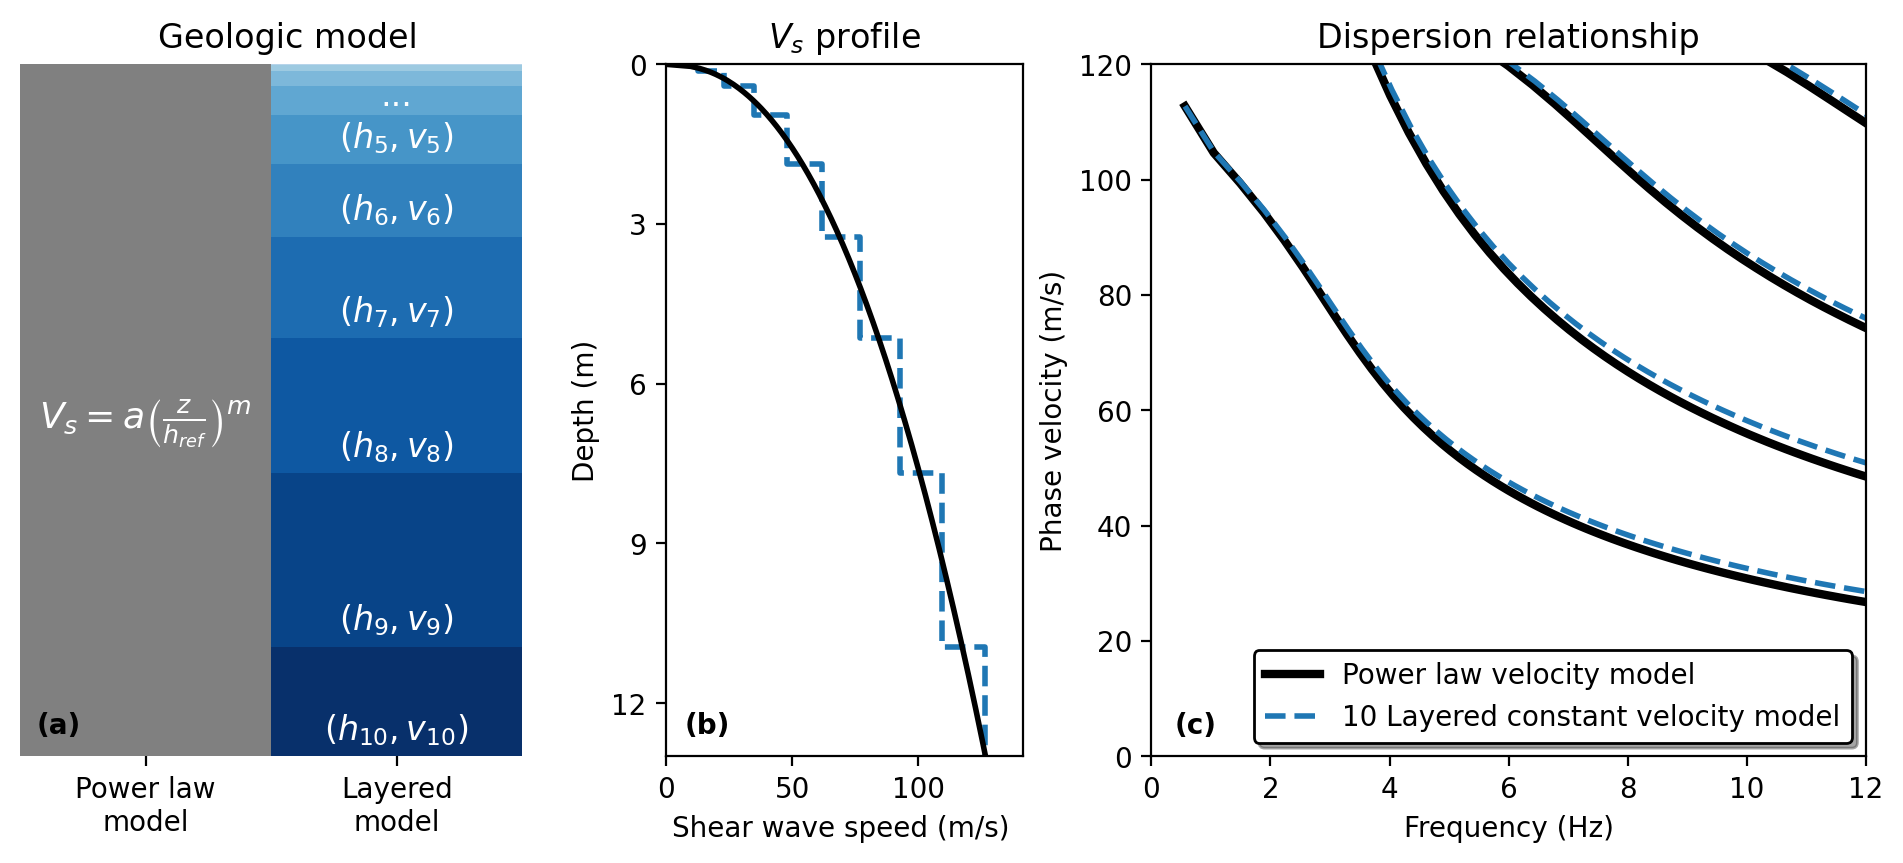

In [10]:
fig = plt.figure(constrained_layout=True,figsize = (9.4,4.2))
gs = GridSpec(1, 9, figure=fig)

ax1 = fig.add_subplot(gs[0:, 0:3])

N = 10
colors = plt.cm.Blues(np.linspace(1,0.3, N))  # blue color from light to dark
layer_height = 1

rect2 = Rectangle((0, 0), 1.5,15,
                  facecolor='gray', edgecolor='none')
ax1.add_patch(rect2)


ax1.text(0.75,15 * 0.55,
        r'$V_{s}=a\left(\frac{z}{h_{ref}}\right)^{m}$',
        ha='center', va='center', fontsize=13, color='white')


for i in range(N):

    y_bottom = x_edges[i+1] - x_edges[i]
    rect = Rectangle((1.5, x_edges[i]), 1.5, x_edges[i+1] - x_edges[i],
                     facecolor=colors[i], edgecolor='none')
    ax1.add_patch(rect)
    
    if i >= 1 and i <=5:
        ax1.text(2.25, x_edges[i] + 0.5,
            rf"$(h_{{{10-i}}},v_{{{10-i}}})$",
            ha='center', va='center', fontsize=12, color='w')
    
ax1.text(2.25, 2.5,
            rf"$(h_{{{10}}},v_{{{10}}})$",
            ha='center', va='center', fontsize=12, color='w')

ax1.text(2.25, 14.4,
            '...',
            ha='center', va='center', fontsize=12, color='w')


ax1.set_xlim(0, 3.2)
ax1.set_ylim(2, 15)

ax1.set_xticks([0.75,2.25],["Power law\nmodel","Layered\nmodel"])
for s in ['left', 'right', 'top', 'bottom']:
    ax1.spines[s].set_visible(False)

ax1.set_yticks([])
ax1.set_title('Geologic model')

########################################################################

ax2 = fig.add_subplot(gs[0:, 3:5])

ax2.plot(v_step, x_step,c = 'tab:blue',ls = '--',lw = 2)
x_plot = np.linspace(0, 15, 400)
ax2.plot(v_true(x_plot), x_plot,label = 'Power law model',c = 'k',lw = 2)

ax2.set_xlabel('Shear wave speed (m/s) ')
ax2.set_ylabel('Depth (m)')
# ax2.legend(shadow = True,edgecolor = 'k')

ax2.set_xlim(0,)
ax2.set_ylim(2,15)
ax2.set_yticks(np.arange(15,0,-3),np.arange(0,15,3))
ax2.set_title(r'$V_{s}$ profile')

# plt.tight_layout()

########################################################################

ax3 = fig.add_subplot(gs[0:, 5::])

ax3.plot(freq1[0::50],c1[0::50],label = 'Power law velocity model',lw = 3,c = 'k')
ax3.plot(freq[0::50],c[0::50],label = '10 Layered constant velocity model',lw = 2,ls = '--',c = 'tab:blue')

ax3.plot(freq1[1::50],c1[1::50],lw = 3,c = 'k')
ax3.plot(freq[1::50],c[1::50],lw = 2,ls = '--',c = 'tab:blue')

ax3.plot(freq1[2::50],c1[2::50],lw = 3,c = 'k')
ax3.plot(freq[2::50],c[2::50],lw = 2,ls = '--',c = 'tab:blue')

ax3.plot(freq1[3::50],c1[3::50],lw = 3,c = 'k')
ax3.plot(freq[3::50],c[3::50],lw = 2,ls = '--',c = 'tab:blue')

ax3.set_xlim(0,12)
ax3.set_ylim(0,120)

ax3.set_xlabel('Frequency (Hz)')
ax3.set_ylabel('Phase velocity (m/s)')

ax3.legend(shadow = True,edgecolor = 'k',loc = 'lower right')
ax3.set_title('Dispersion relationship')

fig.text(0.025, 0.15, '(a)', ha='center', va='center', fontweight='bold')
fig.text(0.37, 0.15,  '(b)', ha='center', va='center', fontweight='bold')
fig.text(0.63, 0.15,  '(c)', ha='center', va='center', fontweight='bold')

# fig.savefig('adv_dia_1222_3.png', dpi=600)

plt.show()